In [1]:
from typing import Literal, TypedDict

from langgraph.graph import StateGraph, START, END



In [2]:
# ----------------------------
# State
# ----------------------------

class GraphState(TypedDict):
    text: str
    sentiment: str
    response: str


In [3]:
# ----------------------------
# Nodes
# ----------------------------

def classify(state: GraphState):
    text = state["text"].lower()

    # Dummy classifier
    sentiment = "positive" if "good" in text else "negative"

    return {"sentiment": sentiment}


def positive_node(state: GraphState):
    return {
        "response": "😊 Thanks for the positive feedback!"
    }


def negative_node(state: GraphState):
    return {
        "response": "😔 Sorry to hear that. We'll work to improve."
    }



In [4]:
# ----------------------------
# Router
# ----------------------------

def route(state: GraphState) -> Literal["positive", "negative"]:
    return state["sentiment"]



In [5]:
# ----------------------------
# Build Graph
# ----------------------------

builder = StateGraph(GraphState)

builder.add_node("classify", classify)
builder.add_node("positive", positive_node)
builder.add_node("negative", negative_node)

builder.add_edge(START, "classify")

builder.add_conditional_edges(
    "classify",
    route,
    # {
    #     "positive": "positive",
    #     "negative": "negative",
    # },
)

builder.add_edge("positive", END)
builder.add_edge("negative", END)

graph = builder.compile()


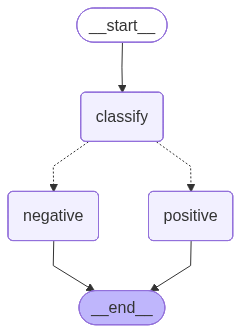

In [6]:
graph

In [7]:

# ----------------------------
# Run
# ----------------------------

result = graph.invoke({
    "text": "This product is really bad!"
})

print(result)

{'text': 'This product is really bad!', 'sentiment': 'negative', 'response': "😔 Sorry to hear that. We'll work to improve."}
